In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def basic_exploration(df):
    print("First 5 rows:")
    display(df.head())

    print("\nShape of dataset:")
    print(df.shape)

    print("\nDataset information:")
    df.info()

    print("\nStatistical summary:")
    display(df.describe(include="all"))

    print("\nMissing values:")
    display(df.isnull().sum())

In [3]:
try:
    student = pd.read_csv("StudentsPerformance.csv")
    print("Dataset loaded successfully from StudentsPerformance.csv")
except FileNotFoundError:
    print("StudentsPerformance.csv not found. Creating a small sample dataset for demonstration.")
    student = pd.DataFrame({
        "gender": ["female", "male", "female", "male", "female", "male", "female", "male"],
        "race/ethnicity": ["group B", "group C", "group B", "group A", "group C", "group D", "group E", "group C"],
        "parental level of education": ["bachelor's degree", "some college", "master's degree", "associate's degree", "high school", "some college", "master's degree", "high school"],
        "lunch": ["standard", "standard", "standard", "free/reduced", "free/reduced", "standard", "standard", "free/reduced"],
        "test preparation course": ["none", "completed", "none", "none", "completed", "completed", "completed", "none"],
        "math score": [72, 69, 90, 47, 76, 88, 95, 55],
        "reading score": [72, 90, 95, 57, 78, 84, 92, 60],
        "writing score": [74, 88, 93, 44, 75, 82, 91, 58]
    })

basic_exploration(student)

StudentsPerformance.csv not found. Creating a small sample dataset for demonstration.
First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,male,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,female,group C,high school,free/reduced,completed,76,78,75



Shape of dataset:
(8, 8)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       8 non-null      object
 1   race/ethnicity               8 non-null      object
 2   parental level of education  8 non-null      object
 3   lunch                        8 non-null      object
 4   test preparation course      8 non-null      object
 5   math score                   8 non-null      int64 
 6   reading score                8 non-null      int64 
 7   writing score                8 non-null      int64 
dtypes: int64(3), object(5)
memory usage: 644.0+ bytes

Statistical summary:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,8,8,8,8,8,8.000000,8.000000,8.000000
unique,2,5,5,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,4,3,2,5,4,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,74.000000,78.500000,75.625000
std,NaN,NaN,NaN,NaN,NaN,16.970563,14.461772,17.095843
min,NaN,NaN,NaN,NaN,NaN,47.000000,57.000000,44.000000
25%,NaN,NaN,NaN,NaN,NaN,65.500000,69.000000,70.000000
50%,NaN,NaN,NaN,NaN,NaN,74.000000,81.000000,78.500000
75%,NaN,NaN,NaN,NaN,NaN,88.500000,90.500000,88.750000



Missing values:


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Find Average Marks in Math, Reading, and Writing

In [4]:
score_columns = ["math score", "reading score", "writing score"]

print("Average scores:")
print(student[score_columns].mean())

Average scores:
math score       74.000
reading score    78.500
writing score    75.625
dtype: float64


## Create a New Column Named average_score

In [5]:
student["average_score"] = student[score_columns].mean(axis=1)
display(student.head())

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,male,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,female,group C,high school,free/reduced,completed,76,78,75,76.333333


## Compare Marks Based on Gender

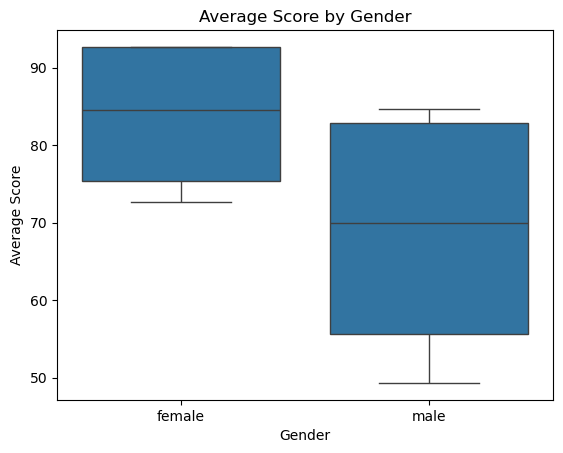

Average score by gender:
gender
female    83.583333
male      68.500000
Name: average_score, dtype: float64


In [6]:
sns.boxplot(data=student, x="gender", y="average_score")
plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

print("Average score by gender:")
print(student.groupby("gender")["average_score"].mean())

## female students perform better in reading and writing, while male students may perform slightly better in math.

## Analyze the Effect of Test Preparation Course

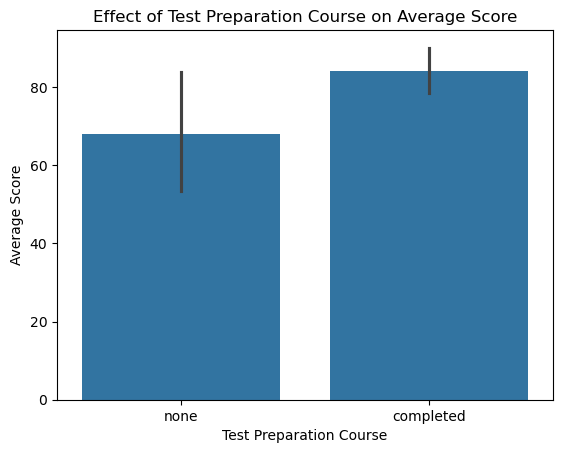

Average score by test preparation course:
test preparation course
completed    84.000000
none         68.083333
Name: average_score, dtype: float64


In [7]:
sns.barplot(data=student, x="test preparation course", y="average_score")
plt.title("Effect of Test Preparation Course on Average Score")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.show()

print("Average score by test preparation course:")
print(student.groupby("test preparation course")["average_score"].mean())

## Students who completed the test preparation course usually show better average scores

## Compare Marks Based on Parental Education

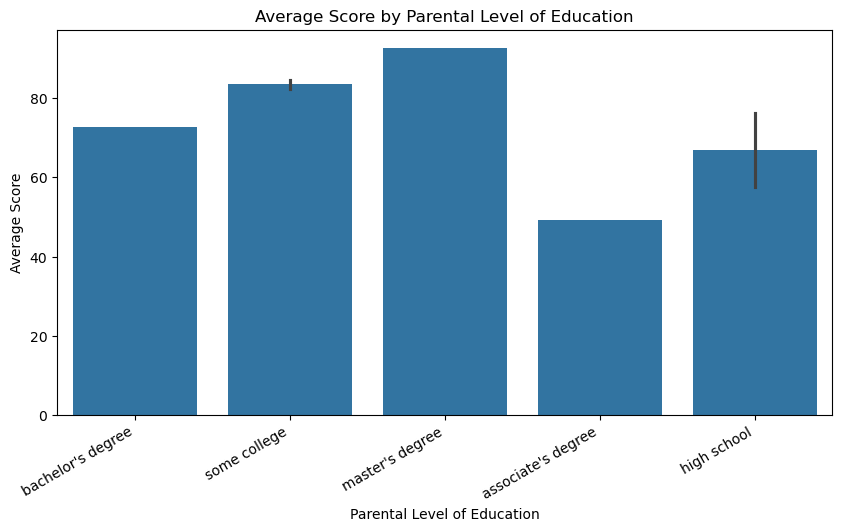

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=student, x="parental level of education", y="average_score")
plt.title("Average Score by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Score")
plt.xticks(rotation=30, ha="right")
plt.show()

##  Students whose parents have higher education levels often show better average performance.

## Score Distribution

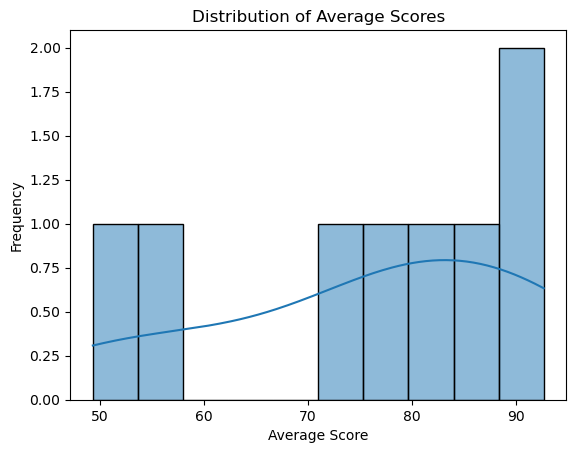

In [9]:
sns.histplot(data=student, x="average_score", bins=10, kde=True)
plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Frequency")
plt.show()

## It helps identify whether most students scored low, average, or high.

## Correlation Heatmap Among Scores

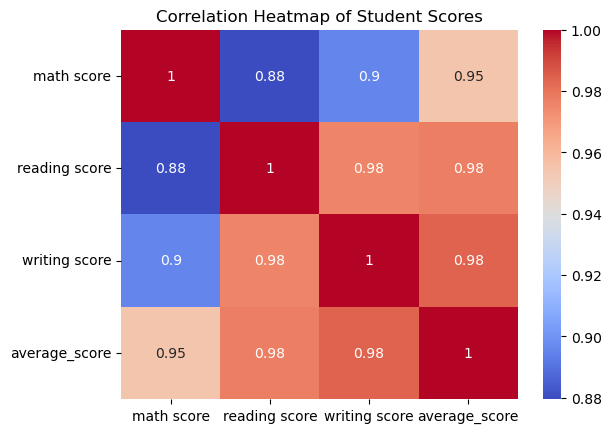

In [10]:
score_corr = student[["math score", "reading score", "writing score", "average_score"]].corr()

sns.heatmap(score_corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Student Scores")
plt.show()

## Reading score and writing score usually have a strong positive correlation. This means students who perform well in reading also tend to perform well in writing.